In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

problem statement - predict the fraud credit card transactions

# Load data

load the data from csv file

In [2]:
df = pd.read_csv("fraudTest.csv")
pd.set_option('display.max_columns', None)
df.head(2)

,sn,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,21-06-2020 12:14,2.291160e+15,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,19-03-1968,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,21-06-2020 12:14,3.573030e+15,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",17-01-1990,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0


 convert dob and trans_data_time from int to datatime dtype 

In [3]:
df["dob"] = pd.to_datetime(df["dob"],dayfirst=True)
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"],dayfirst=True)

 calculating age from dob and trans_date_trans_time

In [4]:
# Convert timedelta to total seconds and divide for approximate years
SECONDS_IN_YEAR = 60 * 60 * 24 * 365.25
df['age_approx']  = round((df["trans_date_trans_time"] - df["dob"]).dt.total_seconds()/ SECONDS_IN_YEAR).astype(int)

 calculating total transactions happened by each card

In [5]:
df["total_transactions_per_card"] = df.groupby("cc_num")["trans_num"].transform("count")

 calculating average amount transacted by the card in its all transactions

In [6]:
df["avg_amt_per_card"] =  df.groupby("cc_num")["amt"].transform("mean")

 card-merchant-transaction

In [7]:
df["card_merchant_txn_count"] = (df.groupby(["cc_num","merchant"])["trans_num"].transform("nunique"))

df["is_first_time_merchant"] = (df["card_merchant_txn_count"] == 1).astype(int)

 calculating city size using city population, dividing into small, medium, large and metro

In [8]:
df["city_size"] = pd.cut(
    df["city_pop"],
    bins=[0,50000,200000,1000000,np.inf],
    labels=["small","medium","large","metro"]
)

 calculating fraud rate in each state

In [9]:
fraud_state_summary = df.groupby("state")["is_fraud"].agg(["sum","count"])
fraud_state_summary.columns = ["fraud_trans_per_state","total_trans_per_state"] 
fraud_state_summary["fraud_rate_per_state"] = (fraud_state_summary["fraud_trans_per_state"]/fraud_state_summary["total_trans_per_state"])*100

In [10]:
df_1 = pd.merge(df,fraud_state_summary.drop(["fraud_trans_per_state","total_trans_per_state"],axis=1),on="state",how="left")

 calculating fraud rate in each category

In [11]:
fraud_cate_summary = df_1.groupby("category")["is_fraud"].agg(["sum","count"])
fraud_cate_summary.columns = ["fraud_trans_per_cate","total_trans_per_cate"] 
fraud_cate_summary["fraud_rate_per_cate"] = (fraud_cate_summary["fraud_trans_per_cate"]/fraud_cate_summary["total_trans_per_cate"])*100

In [12]:
df_2 = pd.merge(df_1,fraud_cate_summary.drop(["fraud_trans_per_cate","total_trans_per_cate"],axis=1),on="category",how="left")

 calculating - is transaction happened in night or not

In [13]:
df_2["time"] = df_2["trans_date_trans_time"].dt.hour
night_hours = [23,24,0,1,2,3,4,5]
df_2["is_night_trans"] = (df_2["time"].isin(night_hours)).astype(int)

 calculating time_gap in every second transaction by each card

In [14]:
df_2 = df_2.sort_values(['cc_num', 'unix_time']).reset_index(drop=True)
df_2["time_gap"] = df_2.groupby("cc_num")["unix_time"].diff().fillna(999999)

 droped all unnecessary columns from dataframe

In [15]:
df_new = df_2.drop(["sn","first","last","street","zip","job","dob","trans_date_trans_time","cc_num","merchant","category","city","state","lat","long","city_pop","trans_num","unix_time","merch_lat","merch_long","time"],axis=1)

 now i have frash dataframe having all useful columns

In [16]:
df_new.head(2)

,amt,gender,is_fraud,age_approx,total_transactions_per_card,avg_amt_per_card,card_merchant_txn_count,is_first_time_merchant,city_size,fraud_rate_per_state,fraud_rate_per_cate,is_night_trans,time_gap
0,124.66,F,0,34,678,66.499484,1,1,small,0.106458,0.127997,0,999999.0
1,78.52,F,0,34,678,66.499484,1,1,small,0.106458,0.208249,0,11994.0


In [17]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 13 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   amt                          555719 non-null  float64 
 1   gender                       555719 non-null  object  
 2   is_fraud                     555719 non-null  int64   
 3   age_approx                   555719 non-null  int64   
 4   total_transactions_per_card  555719 non-null  int64   
 5   avg_amt_per_card             555719 non-null  float64 
 6   card_merchant_txn_count      555719 non-null  int64   
 7   is_first_time_merchant       555719 non-null  int64   
 8   city_size                    555719 non-null  category
 9   fraud_rate_per_state         555719 non-null  float64 
 10  fraud_rate_per_cate          555719 non-null  float64 
 11  is_night_trans               555719 non-null  int64   
 12  time_gap                     555719 non-null

# EDA

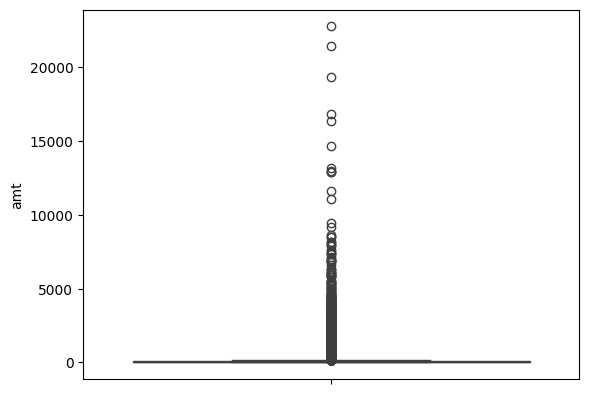

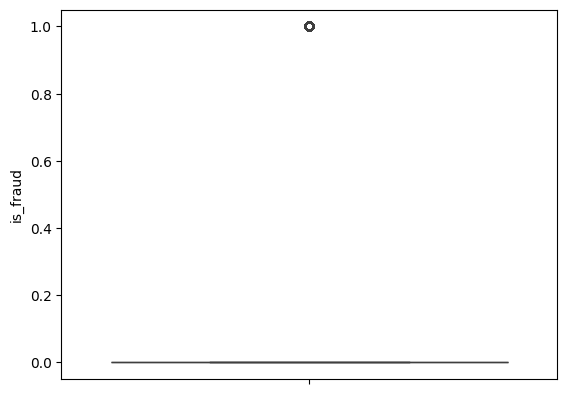

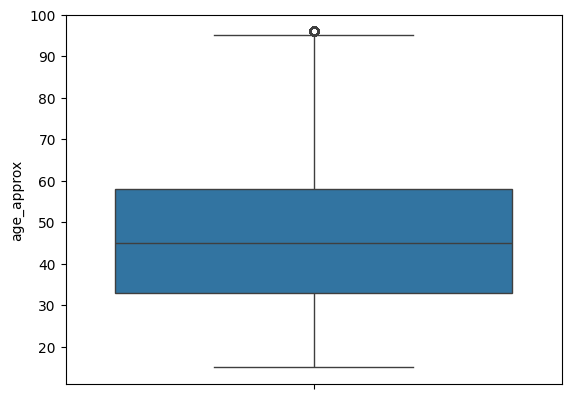

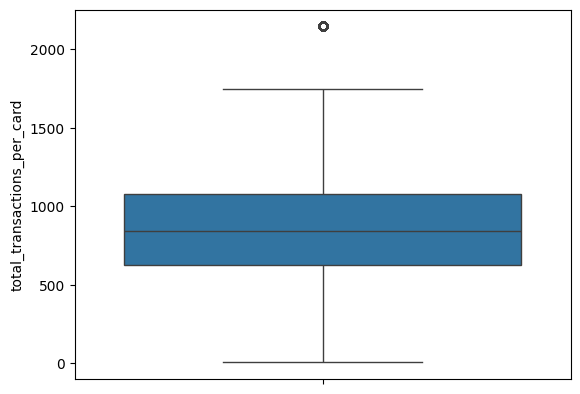

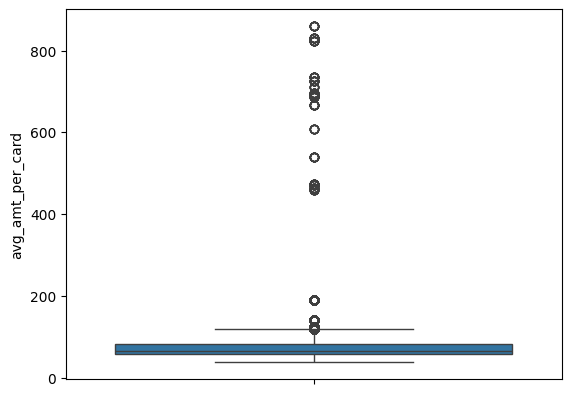

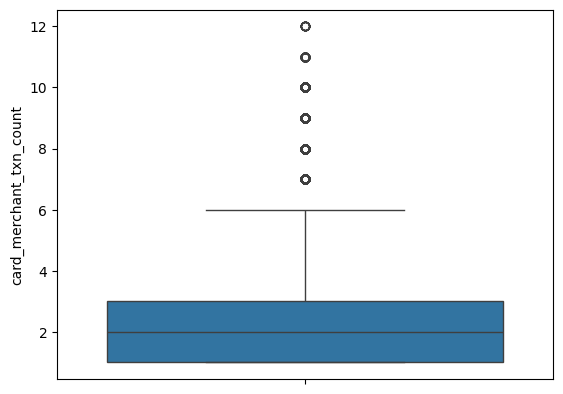

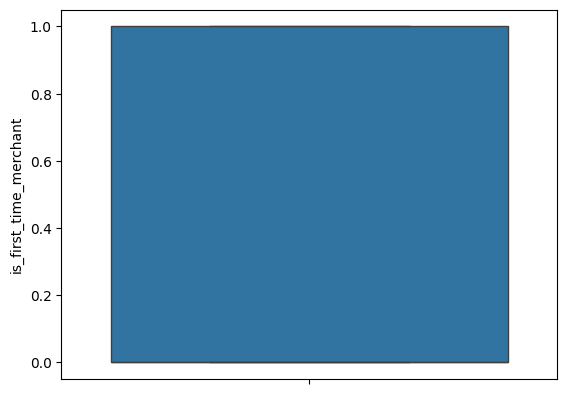

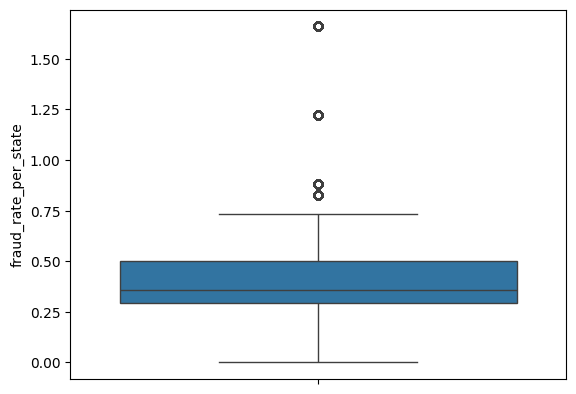

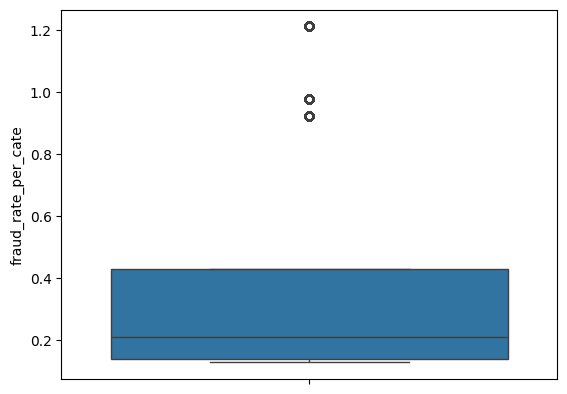

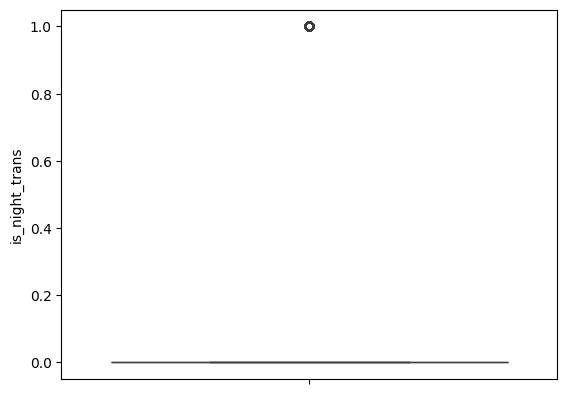

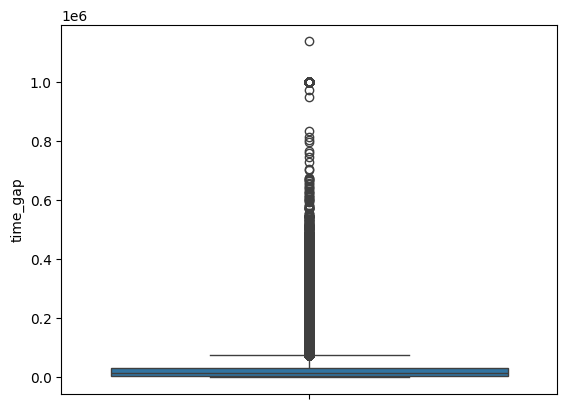

In [18]:
columns = df_new.select_dtypes(include=["int64","float64"]).columns
for col in columns:  
    sns.boxplot(df_new[col])
    plt.show()

there are many values outside the iqr range, i am not going to treat them as outliers because they may be suspecious for fraud

there is no null value and duplicated values

<Axes: xlabel='count', ylabel='gender'>

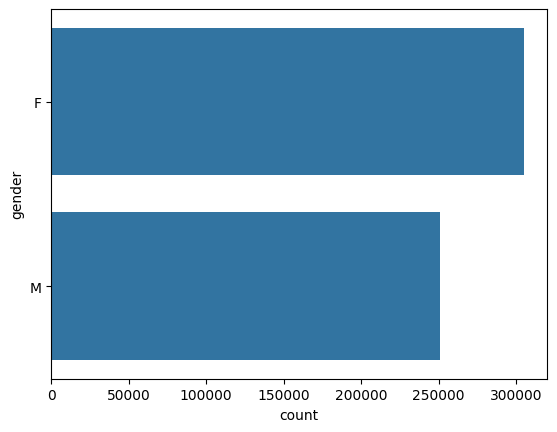

In [19]:
 sns.countplot(df_new["gender"])

# label_encoding

i am using pandas get_dummies method for encoding in gender and city_size columns

In [20]:
df_new_encoded = pd.get_dummies(df_new,columns=["gender","city_size"],drop_first=True)

In [21]:
df_new_encoded.head(2)

,amt,is_fraud,age_approx,total_transactions_per_card,avg_amt_per_card,card_merchant_txn_count,is_first_time_merchant,fraud_rate_per_state,fraud_rate_per_cate,is_night_trans,time_gap,gender_M,city_size_medium,city_size_large,city_size_metro
0,124.66,0,34,678,66.499484,1,1,0.106458,0.127997,0,999999.0,False,False,False,False
1,78.52,0,34,678,66.499484,1,1,0.106458,0.208249,0,11994.0,False,False,False,False


# corelation matrix

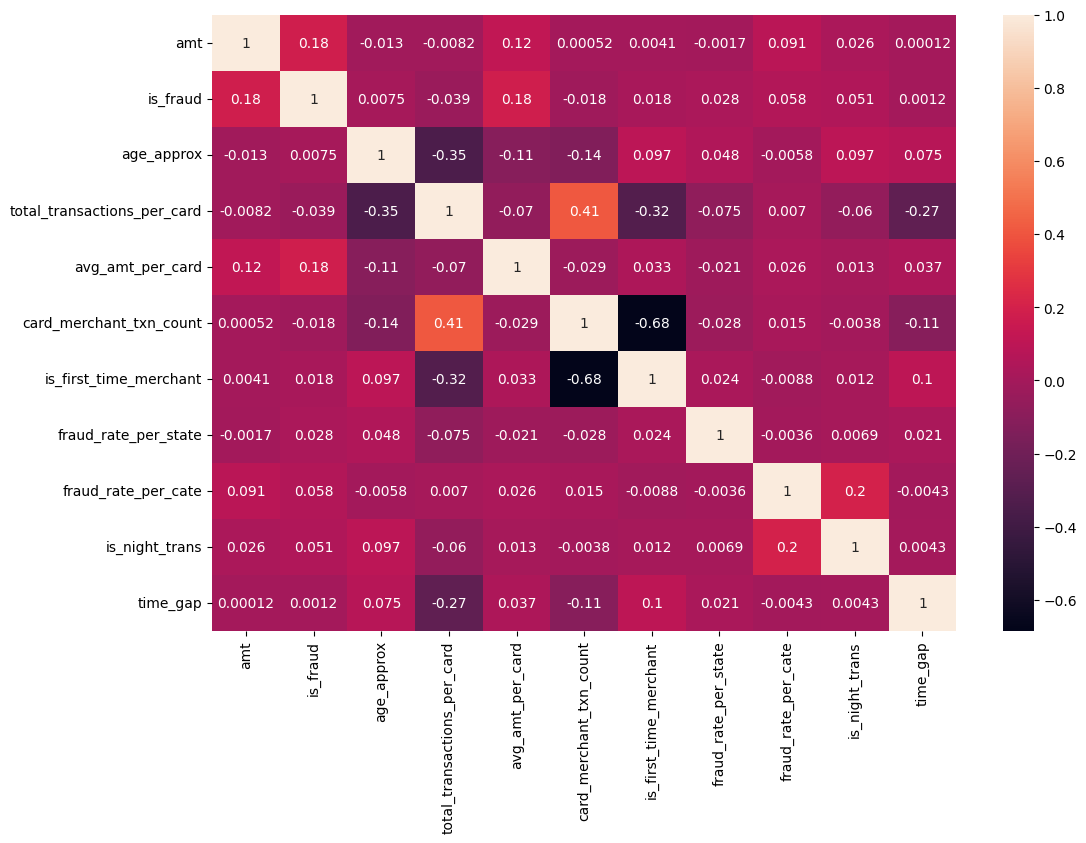

In [22]:
cols = df_new.select_dtypes(include=["int64","float64"]).columns
corr = df_new[cols].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr,annot=True)
plt.show()

# split data

spliting dataframe into train and test 

In [23]:
from sklearn.model_selection import train_test_split
x = df_new_encoded.drop("is_fraud",axis=1)
y= df_new_encoded["is_fraud"]

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)

In [24]:
x_train.head(2)

,amt,age_approx,total_transactions_per_card,avg_amt_per_card,card_merchant_txn_count,is_first_time_merchant,fraud_rate_per_state,fraud_rate_per_cate,is_night_trans,time_gap,gender_M,city_size_medium,city_size_large,city_size_metro
469546,47.95,47,936,64.213825,4,0,0.106458,0.273195,1,16497.0,False,False,False,False
351123,31.09,33,663,59.207526,1,1,0.292753,0.137517,0,49666.0,True,True,False,False


# scaling

In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# for train
x_train_scaled = scaler.fit_transform(x_train)
x_train_scaled_df = pd.DataFrame(x_train_scaled,columns=x_train.columns)

# for test
x_test_scaled = scaler.transform(x_test)
x_test_scaled_df = pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [27]:
x_train_scaled_df.head(2)

,amt,age_approx,total_transactions_per_card,avg_amt_per_card,card_merchant_txn_count,is_first_time_merchant,fraud_rate_per_state,fraud_rate_per_cate,is_night_trans,time_gap,gender_M,city_size_medium,city_size_large,city_size_metro
0,-0.138021,0.007195,0.386269,-0.282101,1.237785,-0.699869,-1.586915,-0.315554,1.741251,-0.211376,-0.909060,-0.321303,-0.268267,-0.161566
1,-0.247466,-0.796013,-0.413627,-0.554667,-0.978956,1.428839,-0.529972,-0.694473,-0.574300,0.382150,1.100037,3.112331,-0.268267,-0.161566


# model Training

## logistic regression

In [28]:
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression(class_weight='balanced',max_iter=1000)
model_lr.fit(x_train_scaled_df,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [29]:
y_pred = model_lr.predict(x_test_scaled_df)

from sklearn.metrics import classification_report,confusion_matrix
report = classification_report(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred)
print(report)
print(cm)

              precision    recall  f1-score   support

           0       1.00      0.91      0.95    166072
           1       0.03      0.78      0.06       644

    accuracy                           0.90    166716
   macro avg       0.51      0.84      0.50    166716
weighted avg       1.00      0.90      0.95    166716

[[150336  15736]
 [   142    502]]


baseline logistic regression is not giving good precision and recall,in fraud detection recall important

## undersampling

In [30]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler()
x_train_rus,y_train_rus = rus.fit_resample(x_train_scaled_df,y_train)

### logistic regression

In [31]:
model_lr_rus = LogisticRegression()
model_lr_rus.fit(x_train_rus,y_train_rus)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [32]:
y_pred = model_lr_rus.predict(x_test_scaled_df)

from sklearn.metrics import classification_report,confusion_matrix
report = classification_report(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred)
print(report)
print(cm)

              precision    recall  f1-score   support

           0       1.00      0.91      0.95    166072
           1       0.03      0.78      0.06       644

    accuracy                           0.91    166716
   macro avg       0.52      0.84      0.51    166716
weighted avg       1.00      0.91      0.95    166716

[[150924  15148]
 [   142    502]]


## Oversampling

### Smote

In [33]:
from imblearn.over_sampling import SMOTE
smote = SMOTE()
x_train_smote,y_train_smote = smote.fit_resample(x_train_scaled_df,y_train)

### logistic regression

In [35]:
model_lr_smote = LogisticRegression()
model_lr_smote.fit(x_train_smote,y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [36]:
y_pred = model_lr_smote.predict(x_test_scaled_df)

from sklearn.metrics import classification_report
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.90      0.95    166072
           1       0.03      0.79      0.06       644

    accuracy                           0.90    166716
   macro avg       0.52      0.85      0.50    166716
weighted avg       1.00      0.90      0.95    166716



### smote-tomek

In [37]:
from imblearn.combine import SMOTETomek
st = SMOTETomek()
x_train_st,y_train_st = st.fit_resample(x_train_scaled_df,y_train)

### logistic regression

In [38]:
model_lr_st = LogisticRegression()
model_lr_st.fit(x_train_st,y_train_st)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [40]:
y_pred = model_lr_st.predict(x_test_scaled_df)

from sklearn.metrics import classification_report
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.91      0.95    166072
           1       0.03      0.79      0.06       644

    accuracy                           0.90    166716
   macro avg       0.52      0.85      0.50    166716
weighted avg       1.00      0.90      0.95    166716



In oversampling recall improved but precision and f1_score not good

# Deicison Tree

In [41]:
from sklearn.tree import DecisionTreeClassifier
model_dt = DecisionTreeClassifier(class_weight="balanced")
model_dt.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [42]:
y_pred = model_dt.predict(x_test)

from sklearn.metrics import classification_report
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    166072
           1       0.74      0.62      0.67       644

    accuracy                           1.00    166716
   macro avg       0.87      0.81      0.84    166716
weighted avg       1.00      1.00      1.00    166716



in decision tree, precision,recall and f1-score is balanced but i am concerned about recall.

# Random Forest

In [44]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(class_weight='balanced',n_estimators=300,max_depth=10)
model_rf.fit(x_train,y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [45]:
y_pred = model_rf.predict(x_test)

from sklearn.metrics import classification_report
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.99      0.99    166072
           1       0.25      0.81      0.38       644

    accuracy                           0.99    166716
   macro avg       0.62      0.90      0.69    166716
weighted avg       1.00      0.99      0.99    166716



random forest improved recall at 0.81

# xgboost

In [32]:
from xgboost import XGBClassifier
neg, pos = y_train.value_counts()
scale_pos_weight = neg / pos
model_xgb = XGBClassifier(scale_pos_weight=scale_pos_weight,eval_metric='logloss',random_state=42)
model_xgb.fit(x_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [33]:
y_pred = model_xgb.predict(x_test)

from sklearn.metrics import classification_report
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    166072
           1       0.51      0.86      0.64       644

    accuracy                           1.00    166716
   macro avg       0.76      0.93      0.82    166716
weighted avg       1.00      1.00      1.00    166716



xgboost is giving overall good precision, highest recall and balanced f1_score

# Random search cv

In [27]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

neg, pos = y_train.value_counts()
scale_pos_weight = neg / pos

model_name = XGBClassifier(scale_pos_weight=scale_pos_weight,eval_metric='logloss')
param_dist ={
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'gamma': [0.1, 0.2, 0.3]
}

random_search = RandomizedSearchCV(
    estimator=model_name,
    param_distributions=param_dist,
    n_iter=10,           
    scoring='f1',  
    cv=5,                
    verbose=1,
    n_jobs=-1,           
    random_state=42
)

random_search.fit(x_train,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.7, ...], 'gamma': [0.1, 0.2, ...], 'learning_rate': [0.05, 0.1, ...], 'max_depth': [3, 4, ...], ...}"
,n_iter,10
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [28]:
print("Best parameter:",random_search.best_params_)
best_model = random_search.best_estimator_
y_pred = best_model.predict(x_test)

from sklearn.metrics import classification_report,confusion_matrix
report = classification_report(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred)
print(report)
print(cm)

Best parameter: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.2, 'gamma': 0.3, 'colsample_bytree': 0.7}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    166072
           1       0.58      0.85      0.69       644

    accuracy                           1.00    166716
   macro avg       0.79      0.93      0.85    166716
weighted avg       1.00      1.00      1.00    166716

[[165680    392]
 [    95    549]]


Here, i got all best values in random search cv, and i will go with it 

# Roc_auc

In [34]:
from sklearn.metrics import roc_curve, auc, roc_auc_score
y_pred_prob = model_xgb.predict_proba(x_test)[:,1]

In [35]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

In [36]:
area = auc(fpr, tpr)

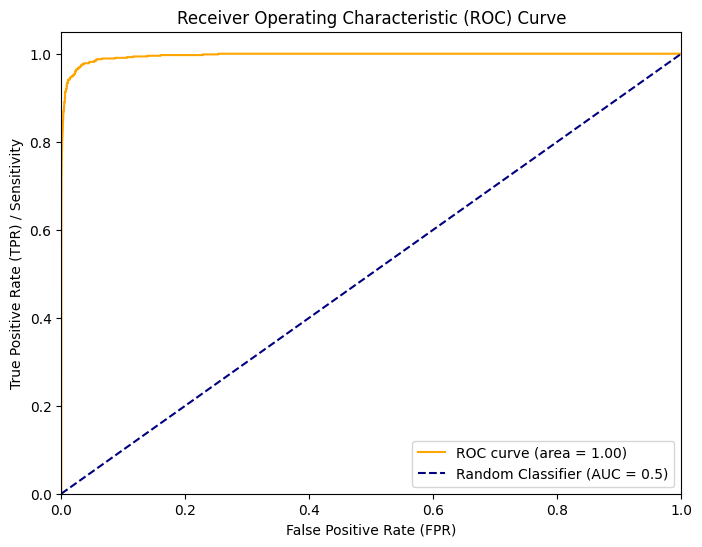

In [37]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', label=f'ROC curve (area = {area:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR) / Sensitivity')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.show()

In imbalanced data, the ROC curve can look deceptively perfect because it includes "True Negatives" (the majority class) in its calculation

# auc_pr curve

In [38]:
from sklearn.metrics import precision_recall_curve, auc
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

In [39]:
area_pr = auc(recall, precision)

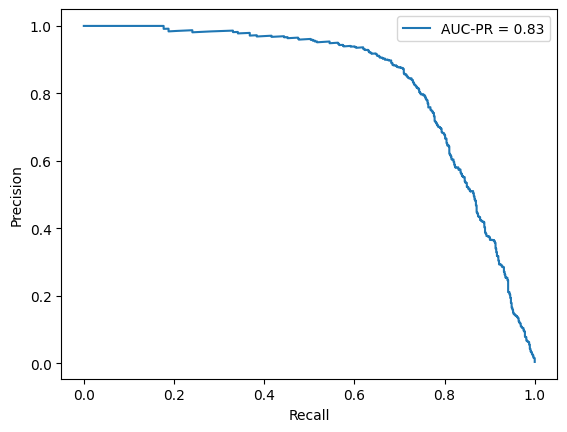

In [40]:
plt.plot(recall, precision, label=f'AUC-PR = {area_pr:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend()
plt.show()

It Completely ignores True Negatives. It focuses solely on the rare Positive class, making it much harder to get a high score unless the model is actually good at catching those rare events

## Threshold tunning

In [41]:
y_pred_proba = model_xgb.predict_proba(x_test)[:,1]

In [42]:
y_pred_proba

array([2.7054025e-06, 2.6164259e-06, 9.4314200e-05, ..., 3.9507620e-04,
       1.9831958e-07, 7.6959094e-07], shape=(166716,), dtype=float32)

In [43]:
y_pred_desired = (y_pred_proba>=0.32).astype(int)

In [44]:
y_pred_desired

array([0, 0, 0, ..., 0, 0, 0], shape=(166716,))

In [45]:
report = classification_report(y_test,y_pred_desired)
print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    166072
           1       0.42      0.89      0.57       644

    accuracy                           0.99    166716
   macro avg       0.71      0.94      0.78    166716
weighted avg       1.00      0.99      1.00    166716



i get hightest recall by threshould tunning - 0.89

# Tracking Experiments using MLFlow

In [79]:
from sklearn.linear_model import LogisticRegression
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV

# xgb
neg, pos = y_train.value_counts()
scale_pos_weight = neg / pos

# random search
model_name = XGBClassifier(scale_pos_weight=scale_pos_weight,eval_metric='logloss')
param_dist ={
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'gamma': [0.1, 0.2, 0.3]
}

models = [
    (
        "Baseline Logistic Regression",
        LogisticRegression(class_weight='balanced',max_iter=1000),
        (x_train_scaled_df,y_train),
        (x_test_scaled_df,y_test)
    ),
    (
        "undersample logistic Regression",
         Pipeline(steps=[("undersample",RandomUnderSampler()),('classifier', LogisticRegression())]),
        (x_train_scaled_df,y_train),
        (x_test_scaled_df,y_test)
    ),
    (
        "oversample(smote) logistic Regression",
        Pipeline(steps=[("oversample",SMOTE()),("classifier",LogisticRegression())]),
        (x_train_scaled_df,y_train),
        (x_test_scaled_df,y_test)       
    ),
    (
       "Decision tree",
        DecisionTreeClassifier(class_weight="balanced"),
        (x_train,y_train),
        (x_test,y_test)
    ),
    (
        "Random Forest",
        RandomForestClassifier(class_weight='balanced',n_estimators=300,max_depth=10),
        (x_train,y_train),
        (x_test,y_test)
    ),
    (
        "XGboost",
        XGBClassifier(scale_pos_weight=scale_pos_weight,eval_metric='logloss',random_state=42),
        (x_train,y_train),
        (x_test,y_test)
    ),
    (
        "RandomSearchCV-xgboost",
        RandomizedSearchCV(
            estimator=model_name,
            param_distributions=param_dist,
            n_iter=10,           
            scoring='f1',  
            cv=5,                
            verbose=1,
            n_jobs=-1,           
            random_state=42
        ),
        (x_train,y_train),
        (x_test,y_test)
    )
    
]

In [96]:
reports=[]
for model_name,model,train_set,test_set in models:
    x_train = train_set[0]
    y_train = train_set[1]
    x_test = test_set[0]
    y_test = test_set[1]

    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    report = classification_report(y_test,y_pred,output_dict=True)
    reports.append(report)
   

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [97]:
import mlflow

In [99]:
mlflow.set_experiment("credit Fraud Detection")
mlflow.set_tracking_uri(uri="http://127.0.0.1:5000/")

2026/02/14 09:45:44 INFO mlflow.tracking.fluent: Experiment with name 'credit Fraud Detection' does not exist. Creating a new experiment.


In [100]:
for i,element in enumerate(models):
    model_name = element[0]
    model = element[1]
    report= reports[i]

    with mlflow.start_run(run_name=model_name):
        mlflow.log_param("model_name",model_name)
        mlflow.log_metric("accuracy",report["accuracy"])
        mlflow.log_metric("recall_class_1",report['1']["recall"])
        mlflow.log_metric("recall_class_0",report['0']["recall"])
        mlflow.log_metric("f1_score_macro",report["macro avg"]["f1-score"])

        if "XGB" in model_name:
            mlflow.xgboost.log_model(model,"model")
        else:
            mlflow.sklearn.log_model(model,"model")

2026/02/14 09:45:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run Baseline Logistic Regression at: http://127.0.0.1:5000/#/experiments/7/runs/d4cd2ac5021a49069b88bbb9fa3e6b75
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7


2026/02/14 09:46:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run undersample logistic Regression at: http://127.0.0.1:5000/#/experiments/7/runs/28be5422b51e460aa9a95a15586836ea
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7


2026/02/14 09:46:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run oversample(smote) logistic Regression at: http://127.0.0.1:5000/#/experiments/7/runs/eae1b512a7af456d8648f3559be2f771
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7


2026/02/14 09:46:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run Decision tree at: http://127.0.0.1:5000/#/experiments/7/runs/9154423756a44a0e8ef2224a39e08376
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7


2026/02/14 09:47:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run Random Forest at: http://127.0.0.1:5000/#/experiments/7/runs/cc157b8e4bbf4a388106dada471dbc4d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7


2026/02/14 09:47:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run XGboost at: http://127.0.0.1:5000/#/experiments/7/runs/5ebea0b96460432c9973e7a4aa3bf1b6
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7


2026/02/14 09:47:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run RandomSearchCV-xgboost at: http://127.0.0.1:5000/#/experiments/7/runs/2352caa8cc23408bbdcfe82068aae5e2
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/7
